# IMDB Sentiment Analysis – Using siebert/sentiment-roberta-large-english  
**Colab-optimized version**  
Model: RoBERTa-large fine-tuned for binary English sentiment (POSITIVE / NEGATIVE)  
Expected accuracy on IMDB test set: ~93–95% (zero-shot / very strong transfer)

In [1]:
# ── Cell 1: Optional – Check GPU availability on local machine

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device     : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("Running on CPU. Inference may be slower.")

PyTorch version: 2.10.0+cu128
CUDA available : True
GPU device     : Tesla T4
GPU memory     : 14.6 GB


In [2]:
# ── Cell 3: Imports
import os
import pickle
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
test_texts   = pickle.load(open("test_texts.pkl", "rb"))
test_labels  = pickle.load(open("test_labels.pkl", "rb"))

print(f"Test set loaded: {len(test_texts):,} examples")

Test set loaded: 25,000 examples


In [5]:
# ── Cell 6: Load model & tokenizer + create pipeline
model_name = "siebert/sentiment-roberta-large-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

pipe = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512,
    batch_size=32                       # good default for T4 GPU
)

print(f"Model & pipeline ready on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: siebert/sentiment-roberta-large-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model & pipeline ready on cuda


In [6]:
# ── Cell 7: Quick single-text prediction demo
def predict_sentiment(text: str):
    result = pipe(text)[0]
    label = result['label']
    score = result['score']
    return label, score

print("\nSample predictions:")
samples = [
    "This movie was amazing! I cried at the end.",
    "Terrible acting, boring plot, do not recommend.",
    "Visually stunning but emotionally empty.",
    "One of the best films of the decade – 10/10."
]

for text in samples:
    label, prob = predict_sentiment(text)
    print(f"→ {label:<9}  confidence: {prob:.4f}    |  {text}")


Sample predictions:
→ POSITIVE   confidence: 0.9989    |  This movie was amazing! I cried at the end.
→ NEGATIVE   confidence: 0.9995    |  Terrible acting, boring plot, do not recommend.
→ NEGATIVE   confidence: 0.9994    |  Visually stunning but emotionally empty.
→ POSITIVE   confidence: 0.9988    |  One of the best films of the decade – 10/10.


In [7]:
# ── Cell 8: Batch evaluation on full test set
class SimpleTextDataset(Dataset):
    def __init__(self, texts): self.texts = texts
    def __len__(self):         return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx]

def evaluate_test_set(batch_size=32):
    dataset = SimpleTextDataset(test_texts)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    predictions   = []
    probabilities = []   # prob of POSITIVE

    for batch_texts in tqdm(loader, desc="Inference"):
        results = pipe(batch_texts)
        for r in results:
            lab   = r['label']
            sc    = r['score']
            pred  = 1 if lab == "POSITIVE" else 0
            pos_p = sc if lab == "POSITIVE" else 1 - sc
            predictions.append(pred)
            probabilities.append(pos_p)

    preds = np.array(predictions)
    probs = np.array(probabilities)

    acc = accuracy_score(test_labels, preds)
    print(f"\nTest Accuracy : {acc:.4f}  ({acc*100:.2f}%)")

    print("\nClassification Report:")
    print(classification_report(test_labels, preds, target_names=["Negative", "Positive"], digits=4))

    cm = confusion_matrix(test_labels, preds)
    print("\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=["True Neg", "True Pos"], columns=["Pred Neg", "Pred Pos"]))

    return preds, probs

# ── Run evaluation
if len(test_texts) > 100:
    print("Starting full evaluation...")
    pred_labels, pred_probs = evaluate_test_set(batch_size=32)
else:
    print("Small test set detected → skipping full evaluation.")

Starting full evaluation...


Inference:   0%|          | 0/782 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Test Accuracy : 0.9558  (95.58%)

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9614    0.9498    0.9555     12500
    Positive     0.9504    0.9618    0.9561     12500

    accuracy                         0.9558     25000
   macro avg     0.9559    0.9558    0.9558     25000
weighted avg     0.9559    0.9558    0.9558     25000


Confusion Matrix:
          Pred Neg  Pred Pos
True Neg     11872       628
True Pos       477     12023


In [8]:
# ── Cell 9: Error Analysis (independent section)

# Create error DataFrame
error_df = pd.DataFrame({
    "text": test_texts,
    "true": test_labels,
    "pred": pred_labels,
    "prob_pos": pred_probs,
    "conf": np.maximum(pred_probs, 1 - pred_probs),
    "correct": np.array(test_labels) == np.array(pred_labels)
})

error_df["error_type"] = np.select(
    [
        (error_df["true"] == 0) & (error_df["pred"] == 1),
        (error_df["true"] == 1) & (error_df["pred"] == 0)
    ],
    ["False Positive", "False Negative"],
    default="Correct"
)

misclassified = error_df[~error_df["correct"]].copy()
misclassified["length"] = misclassified["text"].str.len()

print(f"Misclassified : {len(misclassified):,} / {len(test_texts):,}  ({len(misclassified)/len(test_texts):.2%})")

# Top confident errors
print("\nTop 8 most confident mistakes:")
for _, row in misclassified.sort_values("conf", ascending=False).head(8).iterrows():
    print(f"conf {row['conf']:.4f} | pred {row['pred']} | true {row['true']} | len {row['length']}")
    print(f"{row['text'][:400]}…\n")

Misclassified : 1,105 / 25,000  (4.42%)

Top 8 most confident mistakes:
conf 0.9995 | pred 0 | true 1 | len 742
This was one of the worst Columbo episodes that I have seen, However, I am only in the second season.<br /><br />The typical Columbo activities are both amusing and irritating. His cigar ashes causing him trouble have been seen before, And the bit where he always identifies in some way with the murderer--in this case cooking ,Tho the scene on the TV cooking show distracted from the main theme.<br …

conf 0.9995 | pred 0 | true 1 | len 736
This seemed to be a lackluster film to me that betrays a low budget with poor cinematography and not all that great of a job of editing. It may be of interest to those who know something about submarines during the World War II era, but I recommend that all others beware. Many of the scenes in this film were flat and some of the actors were a bit weak. The story about the men getting called back t…

conf 0.9995 | pred 0 | true 1 | len 675
Th

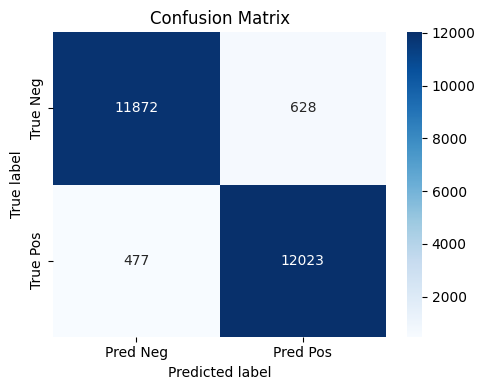

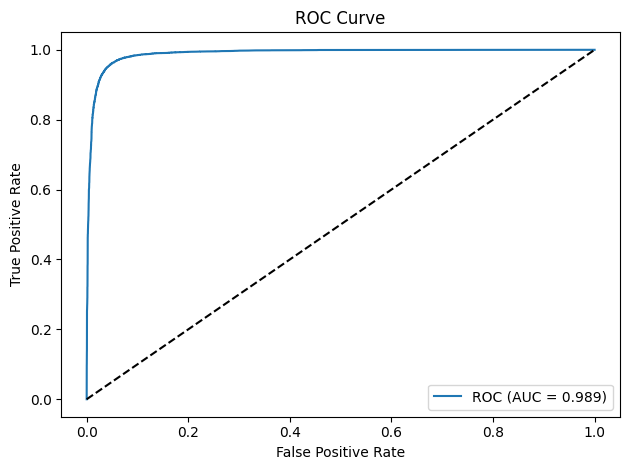

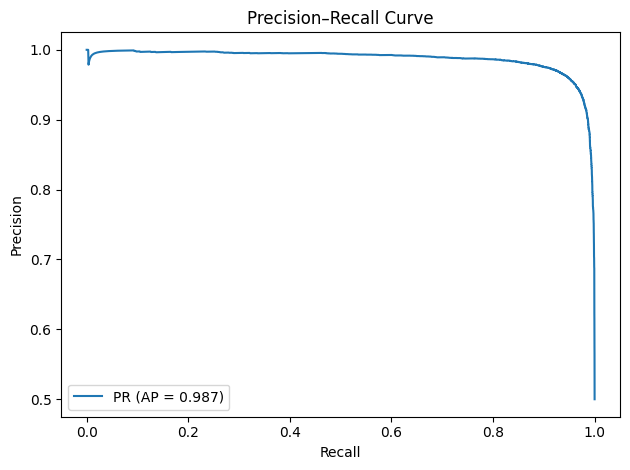

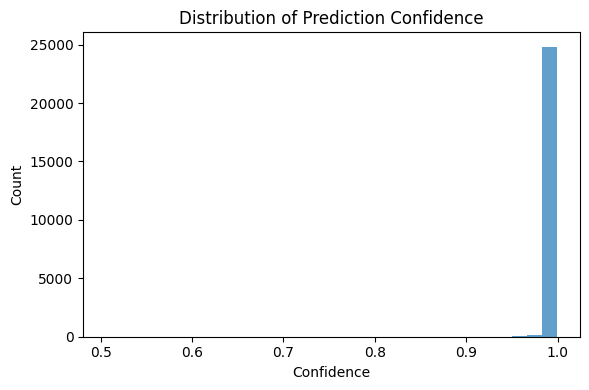

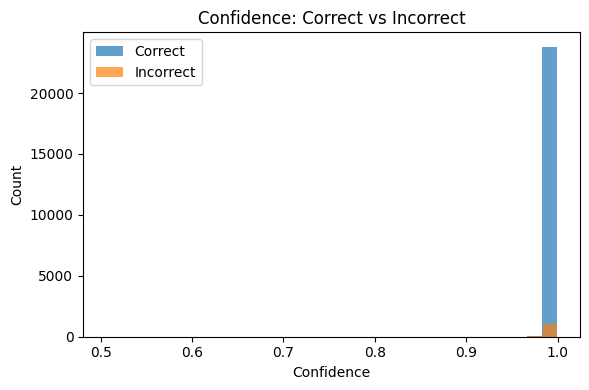

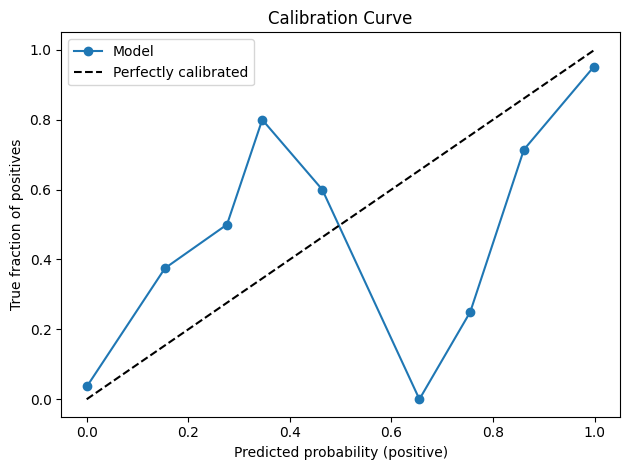

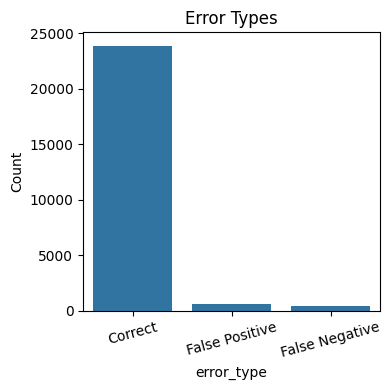

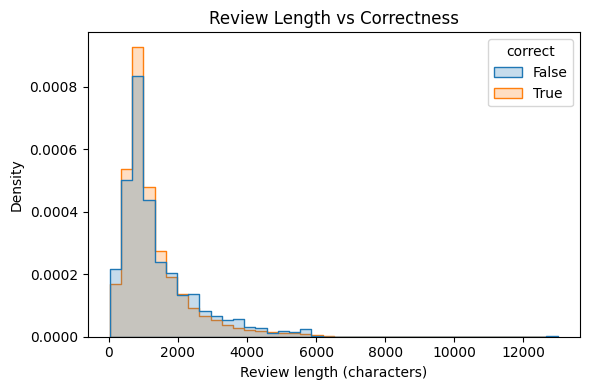

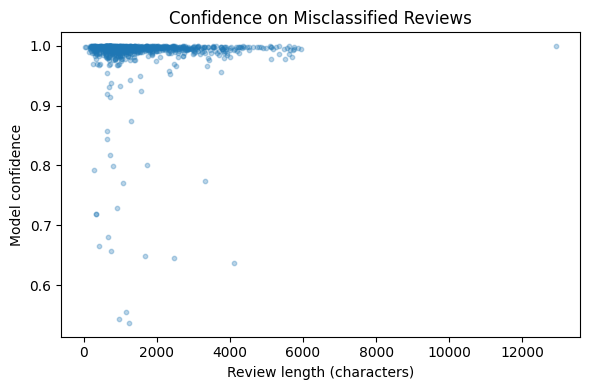

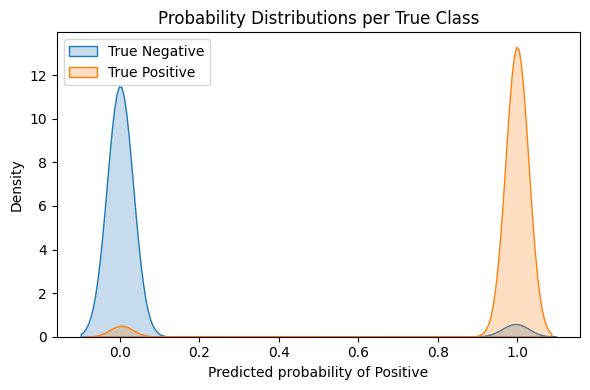

In [9]:
# ── Cell: Visualization – performance and error analysis

# Confusion matrix heatmap
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Neg", "Pred Pos"],
    yticklabels=["True Neg", "True Pos"],
)
plt.title("Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, pred_probs)
auc = roc_auc_score(test_labels, pred_probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision–Recall curve
precision, recall, _ = precision_recall_curve(test_labels, pred_probs)
ap = average_precision_score(test_labels, pred_probs)
plt.figure()
plt.plot(recall, precision, label=f"PR (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Confidence distributions
plt.figure(figsize=(6, 4))
plt.hist(error_df["conf"], bins=30, alpha=0.7)
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Distribution of Prediction Confidence")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(
    error_df[error_df["correct"]]["conf"],
    bins=30,
    alpha=0.7,
    label="Correct",
)
plt.hist(
    error_df[~error_df["correct"]]["conf"],
    bins=30,
    alpha=0.7,
    label="Incorrect",
)
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

# Calibration curve
prob_true, prob_pred = calibration_curve(
    test_labels, pred_probs, n_bins=10, strategy="uniform"
)
plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Predicted probability (positive)")
plt.ylabel("True fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Error types
plt.figure(figsize=(4, 4))
error_counts = error_df["error_type"].value_counts()
sns.barplot(x=error_counts.index, y=error_counts.values)
plt.title("Error Types")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Length vs correctness
error_df["length"] = error_df["text"].str.len()

plt.figure(figsize=(6, 4))
sns.histplot(
    data=error_df,
    x="length",
    hue="correct",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
)
plt.xlabel("Review length (characters)")
plt.title("Review Length vs Correctness")
plt.tight_layout()
plt.show()

# Confidence vs length for misclassified
plt.figure(figsize=(6, 4))
plt.scatter(misclassified["length"], misclassified["conf"], alpha=0.3, s=10)
plt.xlabel("Review length (characters)")
plt.ylabel("Model confidence")
plt.title("Confidence on Misclassified Reviews")
plt.tight_layout()
plt.show()

# Probability distributions per true class
plt.figure(figsize=(6, 4))
sns.kdeplot(
    error_df[error_df["true"] == 0]["prob_pos"],
    label="True Negative",
    fill=True,
)
sns.kdeplot(
    error_df[error_df["true"] == 1]["prob_pos"],
    label="True Positive",
    fill=True,
)
plt.xlabel("Predicted probability of Positive")
plt.title("Probability Distributions per True Class")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Cell 10: Save model & results to Drive (persistent)
SAVE_DIR = f"./roberta-large-imdb-ready"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model saved → {SAVE_DIR}")

# Optional: save error analysis
error_df.to_csv(f"./error_analysis.csv", index=False)
print("Error analysis saved as CSV")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → ./roberta-large-imdb-ready
Error analysis saved as CSV


In [11]:
# ── Cell: Zip the saved model folder → download via browser

import shutil
from google.colab import files

folder_to_zip = "./roberta-large-imdb-ready"  # Corrected folder name
zip_path      = "./roberta-large-sentiment-imdb.zip"

print("Creating zip file ...")
shutil.make_archive(
    base_name = zip_path.replace(".zip", ""),   # removes .zip from name
    format    = "zip",
    root_dir  = folder_to_zip,
    base_dir  = "."
)

print(f"Zip created: {zip_path}")

Creating zip file ...
Zip created: ./roberta-large-sentiment-imdb.zip
